In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv
Saving marketing_campaign.csv to marketing_campaign.csv
Saving train.csv to train.csv


#Task 1

Logistic Regression: 0.9966216216216216 0.9933774834437086 1.0 0.9966777408637874
Random Forest: 1.0 1.0 1.0 1.0


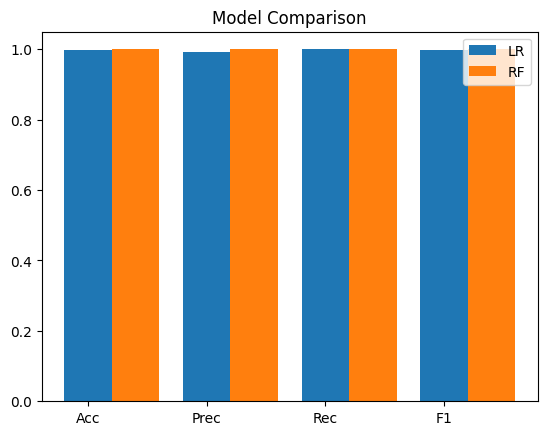

Best: Random Forest


In [33]:
data = pd.read_csv("creditcard.csv")

fraud_mask = data["Class"] == 1
legit_mask = data["Class"] == 0
fraud_data = data[fraud_mask]
legit_data = data[legit_mask]

#doign undersamling
legit_subset = legit_data.iloc[:len(fraud_data)]
balanced_data = pd.concat([fraud_data, legit_subset], axis=0)

X = balanced_data.loc[:, balanced_data.columns != "Class"]
y = balanced_data["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)
log_pre = precision_score(y_test, log_pred)
log_rec = recall_score(y_test, log_pred)
log_f1  = f1_score(y_test, log_pred)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred)

print("Logistic Regression:", log_acc, log_pre, log_rec, log_f1)
print("Random Forest:", rf_acc, rf_pre, rf_rec, rf_f1)

metrics = ["Acc", "Prec", "Rec", "F1"]
lr_vals = [log_acc, log_pre, log_rec, log_f1]
rf_vals = [rf_acc, rf_pre, rf_rec, rf_f1]

x = np.arange(len(metrics))

plt.bar(x, lr_vals, width=0.4, label="LR")
plt.bar(x + 0.4, rf_vals, width=0.4, label="RF")

plt.xticks(x, metrics)
plt.legend()
plt.title("Model Comparison")
plt.show()

if rf_f1 > log_f1:
    print("Best: Random Forest")
else:
    print("Best: Logistic Regression")

#Task 2

/tmp/ipykernel_15387/666247951.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/tmp/ipykernel_15387/666247951.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

LR: 21968.207301023518 32964.72175128479
DT: 26032.59817351598 42881.21491641489


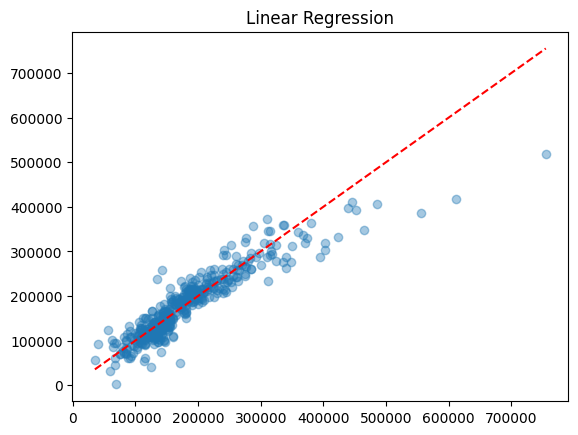

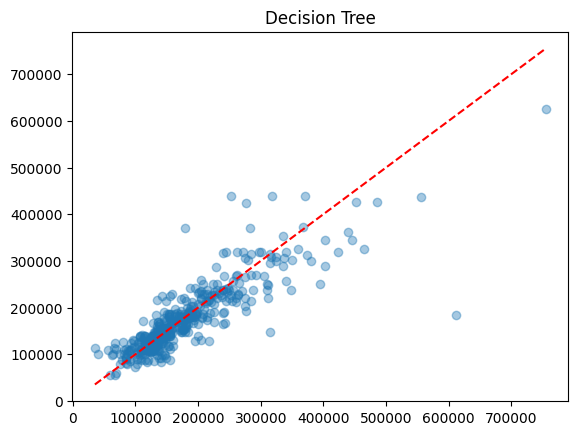

Best: Linear Regression


In [40]:
house = pd.read_csv("train.csv")
numerical_cols = house.select_dtypes(include=np.number).columns.tolist()
categorical_cols = house.select_dtypes(include='object').columns.tolist()

X = house.drop(columns=["SalePrice"])
y = house["SalePrice"]
if "SalePrice" in numerical_cols:
    numerical_cols.remove("SalePrice")

for col in numerical_cols:
    if col in X.columns:
        if X[col].isnull().any():
            X[col].fillna(X[col].median(), inplace=True)

for col in categorical_cols:
    if col in X.columns:
        X[col].fillna('Missing', inplace=True)
        X[col] = X[col].astype("category").cat.codes

y_train, y_test = train_test_split(y, test_size=0.3, random_state=42)
X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
lin = LinearRegression()
lin.fit(X_train, y_train)
lin_pred = lin.predict(X_test)
lin_mae = mean_absolute_error(y_test, lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))

tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))

print("LR:", lin_mae, lin_rmse)
print("DT:", tree_mae, tree_rmse)

plt.scatter(y_test, lin_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Linear Regression")
plt.show()

plt.scatter(y_test, tree_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Decision Tree")
plt.show()
if lin_rmse < tree_rmse:
    print("Best: Linear Regression")
else:
    print("Best: Decision Tree")

#task 3

/tmp/ipykernel_15387/418969326.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cust["Income"].fillna(cust["Income"].median(), inplace=True)


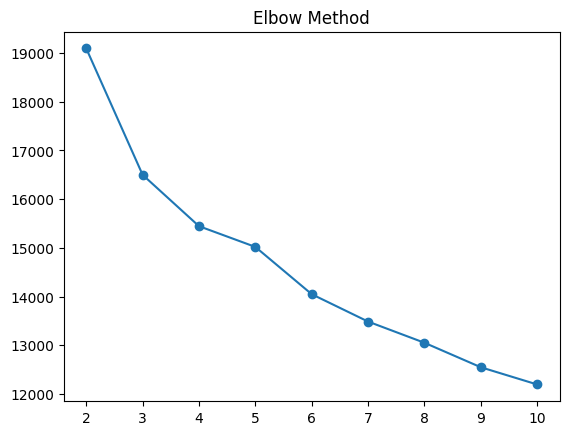

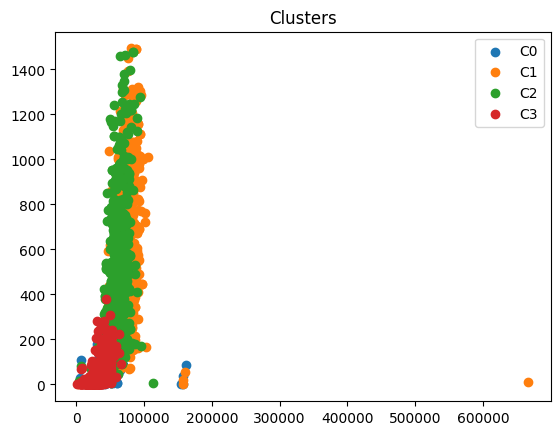

Cluster counts:
Cluster
3    596
2    585
1    534
0    525
Name: count, dtype: int64


In [42]:
from sklearn.cluster import KMeans
cust = pd.read_csv("marketing_campaign.csv", sep="\t")

cust = cust[["Income", "Recency", "MntWines", "MntFruits","MntMeatProducts", "MntFishProducts","MntSweetProducts",
             "MntGoldProds","NumWebPurchases", "NumStorePurchases","NumCatalogPurchases", "Kidhome", "Teenhome"]]
cust["Income"].fillna(cust["Income"].median(), inplace=True)
scaler = StandardScaler()
X = scaler.fit_transform(cust)

k_vals = list(range(2, 11))
wcss = []

for k in k_vals:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    wcss.append(model.inertia_)

plt.plot(k_vals, wcss, marker="o")
plt.title("Elbow Method")
plt.show()

final_model = KMeans(n_clusters=4, random_state=42)
labels = final_model.fit_predict(X)
cust["Cluster"] = labels

for i in range(4):
    subset = cust[cust["Cluster"] == i]
    plt.scatter(subset["Income"], subset["MntWines"], label=f"C{i}")

plt.legend()
plt.title("Clusters")
plt.show()
print("Cluster counts:")
print(cust["Cluster"].value_counts())